In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## Basics: Linear Algebra

### Scalars, Vectors, Matrices, and Tensors

In linear algebra, data can be organized in different structures:

- **Scalar**: A single numerical value.
- **Vector**: An ordered list of numbers.
- **Matrix**: A 2D array of numbers.
- **Tensor**: A higher-dimensional generalization of matrices.



In [ ]:

# Scalar
a = 3.0
print("Scalar:", a)

# Vector
x = np.array([1, 2, 3])
print("\nVector:\n", x)

# Matrix
A = np.array([[1, 2],
              [3, 4]])
print("\nMatrix:\n", A)

# Tensor (3D array)
T = np.array([[[1, 2], [3, 4]],
              [[5, 6], [7, 8]]])
print("\nTensor shape:", T.shape)

### Matrix Multiplication

Matrix multiplication represents linear transformations.

- Matrix–Vector multiplication transforms a vector.
- Matrix–Matrix multiplication composes transformations.

This operation is central in neural networks.

In [ ]:
A = np.array([[1, 2],
              [3, 4]])
x = np.array([5, 6])

b = A @ x
print("A @ x =\n", b)

B = np.eye(2)
C = A @ B
print("\nA @ B =\n", C)

### Identity and Inverse Matrices

- The identity matrix leaves vectors unchanged.
- The inverse matrix reverses a transformation.

A matrix is invertible only if its determinant is nonzero.

In [ ]:
A = np.array([[2, 1],
              [1, 3]])

I = np.eye(2)
A_inv = np.linalg.inv(A)

print("Identity matrix:\n", I)
print("\nInverse of A:\n", A_inv)
print("\nCheck A @ A_inv:\n", A @ A_inv)

### Special Types of Matrices

- Diagonal matrix
- Symmetric matrix
- Orthonormal matrix

These structures simplify many computations in ML.

In [ ]:
# Diagonal
D = np.diag([1, 2, 3])
print("Diagonal matrix:\n", D)

# Symmetric
S = np.array([[2, 1],
              [1, 3]])
print("\nIs symmetric? \n", np.allclose(S, S.T))

# Orthonormal (rotation)
theta = np.pi / 4
Q = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
print("\nQ^T Q =\n", Q.T @ Q)

### Linear Systems

A linear system has the form:

A x = b

Many ML problems can be expressed this way.

In [ ]:
A = np.array([[2, 1],
              [1, 3]])
b = np.array([1, 2])

x = np.linalg.solve(A, b)
print("Solution x:\n", x)

### Linear Dependence and Rank

Rank indicates the number of independent rows or columns.

Low rank implies redundant information.

In [ ]:
X = np.array([[1, 2],
              [2, 4]])

print("Rank:", np.linalg.matrix_rank(X))

### Dot Product

The dot product measures similarity and angle between vectors.

If it equals zero, vectors are orthogonal.

In [ ]:
u = np.array([1, 3, -5])
v = np.array([4, -2, -1])

print("Dot product:", np.dot(u, v))

### Inner Product

The inner product generalizes the dot product to abstract spaces.

In ℝⁿ, it coincides with the standard dot product.

In [ ]:
u = np.array([1, 2, 3])
v = np.array([4, 5, 6])

print("Inner product:", np.inner(u, v))

### Norms

Norms measure the size of vectors.

Important norms in ML:

- L2 (Euclidean)
- L1 (Manhattan)
- L∞ (Max norm)

In [1]:
x = np.array([3, -4])

print("L2 norm:", np.linalg.norm(x))
print("L1 norm:", np.linalg.norm(x, ord=1))
print("L∞ norm:", np.linalg.norm(x, ord=np.inf))

NameError: name 'np' is not defined

### Eigenvalues and Eigendecomposition

Eigenvectors keep their direction after transformation.

A matrix can be factorized as:

\begin{equation}
A = Q \Lambda Q^{-1}
\end{equation}

This is fundamental in PCA.

- $Q$ is a matrix whose columns are the eigenvectors of $A$.
- $\Lambda$ is a diagonal matrix containing the eigenvalues of $A$.

In [ ]:
A = np.array([[2, 1],
              [1, 2]])

# Compute eigenvalues and eigenvectors
eigvals, eigvecs = np.linalg.eig(A)

# Q = matrix of eigenvectors
Q = eigvecs

# Lambda = diagonal matrix of eigenvalues
Lambda = np.diag(eigvals)

# Inverse of Q
Q_inv = np.linalg.inv(Q)

# Reconstruct A
A_reconstructed = Q @ Lambda @ Q_inv

print("Original A:\n", A)
print("\nQ:\n", Q)
print("\nLambda:\n", Lambda)
print("\nQ^-1:\n", Q_inv)

print("\nReconstructed A = Q Λ Q^-1:\n", A_reconstructed)

# Check if they are equal (within numerical precision)
print("\nAre they equal?", np.allclose(A, A_reconstructed))

### Singular Value Decomposition (SVD)

SVD factorizes any matrix:

A = U Σ Vᵀ

It is widely used in dimensionality reduction and PCA.

### Singular Value Decomposition (SVD)

The **Singular Value Decomposition (SVD)** of any matrix $A \in \mathbb{R}^{m \times n}$ is given by:

\begin{equation}
A = U \Sigma V^T
\end{equation}

where:

- $U \in \mathbb{R}^{m \times m}$ is an orthogonal matrix containing the **left singular vectors**.
- $\Sigma \in \mathbb{R}^{m \times n}$ is a diagonal matrix containing the **singular values**.
- $V \in \mathbb{R}^{n \times n}$ is an orthogonal matrix containing the **right singular vectors**.

**Properties**

- SVD generalizes eigendecomposition to **non-square and non-symmetric matrices**.
- It is widely used in **Principal Component Analysis (PCA)** and **dimensionality reduction**.

In [ ]:
import numpy as np

# Example matrix A (can be rectangular)
A = np.array([[3, 1],
              [1, 3],
              [1, 1]])

# Compute the Singular Value Decomposition
# A = U Σ V^T
# NumPy returns:
# U  -> matrix of left singular vectors
# singular_values  -> vector containing the singular values
# VT -> transpose of the matrix V (right singular vectors)
U, singular_values, VT = np.linalg.svd(A)

# Build the diagonal matrix Σ from the singular values
Sigma = np.zeros((U.shape[0], VT.shape[0]))
Sigma[:len(singular_values), :len(singular_values)] = np.diag(singular_values)

# Reconstruct the matrix using the theoretical formula
# A = U Σ V^T
A_reconstructed = U @ Sigma @ VT

print("Original matrix A:\n", A)

print("\nMatrix U (left singular vectors):\n", U)

print("\nMatrix Σ (rectangular matrix with singular values on the main diagonal):\n", Sigma)

print("\nMatrix V^T (transpose of right singular vectors):\n", VT)

print("\nReconstructed matrix U Σ V^T:\n", A_reconstructed)

# Verify that the reconstruction matches A (up to numerical precision)
print("\nDoes U Σ V^T equal A?", np.allclose(A, A_reconstructed))

## Basics: Analysis

### Local and Global Minima

A local minimum is lower than nearby points.
A global minimum is the lowest point overall.

Optimization algorithms aim to find global minima.

In [ ]:
import matplotlib.pyplot as plt

def f(x):
    return x**4 - 2*x**2 + 0.5*x + 1

x = np.linspace(-2, 2, 400)
plt.plot(x, f(x))
plt.title("Local and Global Minima Illustration")
plt.show()

### Derivative

The derivative measures instantaneous rate of change.

It represents the slope of the function at a point.

In [ ]:
def f(x):
    return x**2

def derivative(f, x, h=1e-5):
    return (f(x + h) - f(x)) / h

print("Derivative at x=3:", derivative(f, 3))

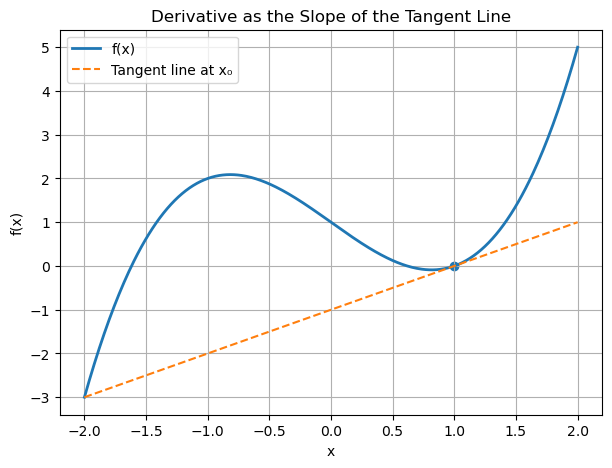

In [2]:


# ---------------------------------------------------------
# Example function
# ---------------------------------------------------------
def f(x):
    return x**3 - 2*x + 1

# Analytical derivative of f(x)
def df(x):
    return 3*x**2 - 2


# ---------------------------------------------------------
# Point where we compute the derivative
# ---------------------------------------------------------
x0 = 1.0
y0 = f(x0)
slope = df(x0)


# ---------------------------------------------------------
# Tangent line at x0
# ---------------------------------------------------------
def tangent(x):
    return y0 + slope*(x - x0)


# ---------------------------------------------------------
# Generate points for plotting
# ---------------------------------------------------------
x = np.linspace(-2, 2, 400)

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------
plt.figure(figsize=(7,5))

# Function
plt.plot(x, f(x), label="f(x)", linewidth=2)

# Tangent line
plt.plot(x, tangent(x), "--", label="Tangent line at x₀")

# Point of tangency
plt.scatter([x0], [y0])

# Labels
plt.title("Derivative as the Slope of the Tangent Line")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)

plt.show()

### Gradient

The gradient is the vector of partial derivatives.

It points in the direction of steepest ascent.

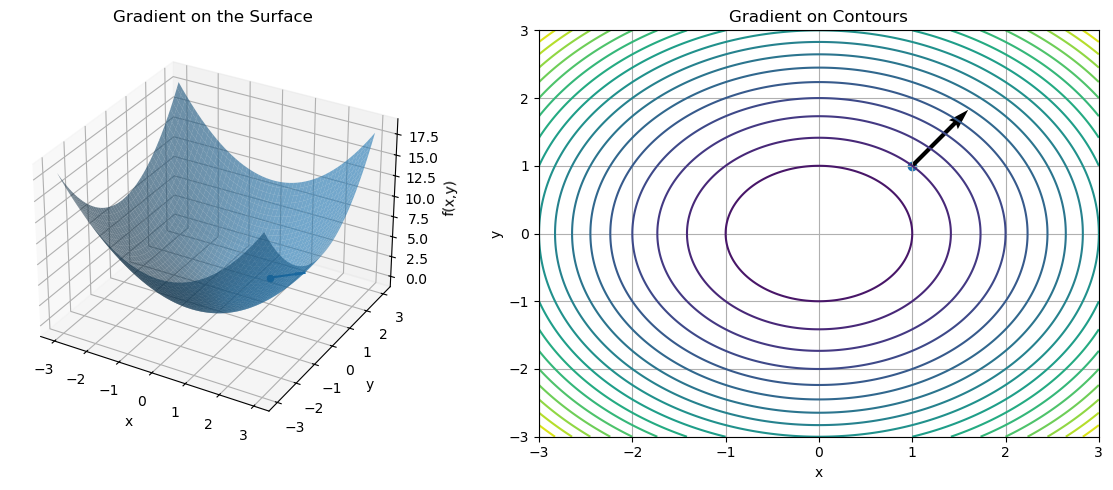

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Define function
# ---------------------------------------------------------
def f(x, y):
    return x**2 + y**2

# Gradient
def grad_f(x, y):
    return np.array([2*x, 2*y])

# ---------------------------------------------------------
# Point where gradient is evaluated
# ---------------------------------------------------------
x0, y0 = 1, 1
z0 = f(x0, y0)

grad = grad_f(x0, y0)

# ---------------------------------------------------------
# Create grid
# ---------------------------------------------------------
x = np.linspace(-3, 3, 200)
y = np.linspace(-3, 3, 200)

X, Y = np.meshgrid(x, y)
Z = f(X, Y)

# ---------------------------------------------------------
# Create figure with two subplots
# ---------------------------------------------------------
fig = plt.figure(figsize=(12,5))

# ---------------------------------------------------------
# Plot 1: 3D surface + gradient
# ---------------------------------------------------------
ax1 = fig.add_subplot(121, projection='3d')

ax1.plot_surface(X, Y, Z, alpha=0.6)

ax1.scatter(x0, y0, z0)

ax1.quiver(x0, y0, z0,
           grad[0], grad[1], 0,
           length=1,
           normalize=True)

ax1.set_title("Gradient on the Surface")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("f(x,y)")


# ---------------------------------------------------------
# Plot 2: Contour plot + gradient
# ---------------------------------------------------------
ax2 = fig.add_subplot(122)

ax2.contour(X, Y, Z, levels=20)

ax2.scatter(x0, y0)

ax2.quiver(x0, y0, grad[0], grad[1], scale=20)

ax2.set_title("Gradient on Contours")
ax2.set_xlabel("x")
ax2.set_ylabel("y")

ax2.grid(True)

plt.tight_layout()
plt.show()

### Chain Rule

If y = f(g(x)), then:

dy/dx = (dy/du) · (du/dx)

This rule is fundamental in backpropagation.

In [ ]:
def dy_dx(x):
    return 2*(3*x + 1) * 3

print("Derivative at x=2:", dy_dx(2))

### Jacobian Matrix

The Jacobian contains all first-order partial derivatives
of a vector-valued function.

In [ ]:
def jacobian(x):
    return np.array([
        [2*x[0], 0],
        [x[1], x[0]]
    ])

print("Jacobian:\n", jacobian(np.array([2.0, 3.0])))

### Hessian Matrix

The Hessian contains second-order derivatives.

It describes curvature.

In [ ]:
def hessian():
    return np.array([[2, 0],
                     [0, 2]])

print("Hessian:\n", hessian())

### Taylor Series Approximation

Taylor series approximate a function locally
using a polynomial expansion.

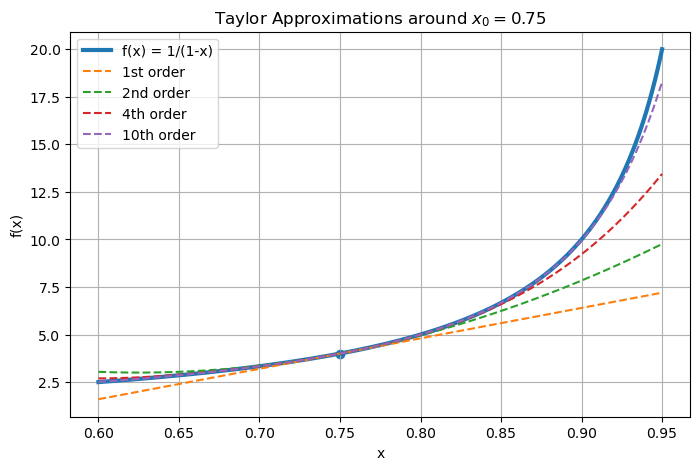

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import math

# ---------------------------------------------------------
# Function
# ---------------------------------------------------------
def f(x):
    return 1/(1-x)

# ---------------------------------------------------------
# Expansion point
# ---------------------------------------------------------
x0 = 0.75

# ---------------------------------------------------------
# Taylor approximation function
# ---------------------------------------------------------
def taylor(x, order):
    s = 0
    for n in range(order+1):
        derivative = math.factorial(n) / (1-x0)**(n+1)
        term = derivative / math.factorial(n) * (x-x0)**n
        s += term
    return s


# ---------------------------------------------------------
# Domain
# ---------------------------------------------------------
x = np.linspace(0.6, 0.95, 400)

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------
plt.figure(figsize=(8,5))

plt.plot(x, f(x), linewidth=3, label="f(x) = 1/(1-x)")

plt.plot(x, taylor(x,1), "--", label="1st order")
plt.plot(x, taylor(x,2), "--", label="2nd order")
plt.plot(x, taylor(x,4), "--", label="4th order")
plt.plot(x, taylor(x,10), "--", label="10th order")

plt.scatter([x0], [f(x0)])

plt.title("Taylor Approximations around $x_0 = 0.75$")
plt.xlabel("x")
plt.ylabel("f(x)")

plt.legend()
plt.grid(True)

plt.show()